In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples, get_wasserstein_dist, get_delta_R_neighbors_numba_exact, get_delta_R_neighbors_kdtree
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d


plt.style.use("../science.mplstyle")

In [2]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
NUM_BDTS = 10

collections = [
    "InnerTrackerBarrelCollection",
    "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]


ZUKO_ID = "NCSF"
NAME = "M_4096_rphi"
NUM_COND_INPUTS = 0
SEED = 8

EVALUATE_SAMPLES = False

FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []



In [3]:
# load in samples

all_data_dir, all_samples_dir = {}, {}
bins_dict, bins_dict_preproc = {}, {}
aucs = {}

for col_name in collections:
    small_id = ''.join([c for c in col_name if c.isupper()])
    data, _, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1)
    all_data_dir[col_name] = data
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
    with open(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/results.txt") as ifile:
        aucs[col_name]=  ifile.readlines()[-1]
   

# if FEATURES == "rphi":
#     r = np.sqrt(flow_samples[:, 1]**2 + flow_samples[:, 2]**2)
#     theta = np.arctan2(flow_samples[:, 2], flow_samples[:, 1])
#     flow_samples[:,1] = r
#     flow_samples[:,2] = theta

    bins_dict[col_name] = {}
    bins_dict_preproc[col_name] = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}
    
    for i in range(data.shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(data[:,i] - 3), np.max(data[:,i] + 3), NUM_BINS) 

In [4]:
print(aucs)

{'InnerTrackerBarrelCollection': 'auc 0.6609302110158761 pm 0.0003451601975699345. best epoch [999, 999, 999, 999, 999] of 1000.\n', 'InnerTrackerEndcapCollection': 'auc 0.9534060053467389 pm 6.468045688111406e-05. best epoch [999, 999, 999, 999, 999] of 1000.\n', 'OuterTrackerBarrelCollection': 'auc 0.6633851218466402 pm 0.000365721684501447. best epoch [998, 999, 999, 999, 999] of 1000.\n', 'OuterTrackerEndcapCollection': 'auc 0.9889441154081672 pm 8.525020977334365e-06. best epoch [999, 999, 999, 999, 999] of 1000.\n', 'VertexBarrelCollection': 'auc 0.6788505126627079 pm 0.0006966959482084742. best epoch [994, 999, 999, 999, 999] of 1000.\n', 'VertexEndcapCollection': 'auc 0.956030588959744 pm 1.1035712689682064e-05. best epoch [999, 999, 999, 999, 999] of 1000.\n'}


In [5]:
"""
for col_name in collections:

    print(col_name)
    plot_hists_1d({"data":all_data_dir[col_name], "samples": all_samples_dir[col_name]}, bins_dict[col_name], log_dims=log_vars, labels=feature_labels)
    plt.savefig(f"figures/{col_name}_1d.png")

    # plot x-y
    x_lim = np.max(all_data_dir[col_name][:,1])
    fig, ax = plt.subplots(1, 2, figsize = (20, 10))
    ax[0].scatter(all_data_dir[col_name][:,1]*np.cos(all_data_dir[col_name][:,2]), all_data_dir[col_name][:,1]*np.sin(all_data_dir[col_name][:,2]), s = 0.00001)
    ax[0].set_xlim(-x_lim, x_lim)
    ax[0].set_ylim(-x_lim, x_lim)
    
    ax[1].scatter(all_samples_dir[col_name][:,1]*np.cos(all_samples_dir[col_name][:,2]), all_samples_dir[col_name][:,1]*np.sin(all_samples_dir[col_name][:,2]), s = 0.00001)
    ax[1].set_xlim(-x_lim, x_lim)
    ax[1].set_ylim(-x_lim, x_lim)
    plt.show()
"""  
   


'\nfor col_name in collections:\n\n    print(col_name)\n    plot_hists_1d({"data":all_data_dir[col_name], "samples": all_samples_dir[col_name]}, bins_dict[col_name], log_dims=log_vars, labels=feature_labels)\n    plt.savefig(f"figures/{col_name}_1d.png")\n\n    # plot x-y\n    x_lim = np.max(all_data_dir[col_name][:,1])\n    fig, ax = plt.subplots(1, 2, figsize = (20, 10))\n    ax[0].scatter(all_data_dir[col_name][:,1]*np.cos(all_data_dir[col_name][:,2]), all_data_dir[col_name][:,1]*np.sin(all_data_dir[col_name][:,2]), s = 0.00001)\n    ax[0].set_xlim(-x_lim, x_lim)\n    ax[0].set_ylim(-x_lim, x_lim)\n\n    ax[1].scatter(all_samples_dir[col_name][:,1]*np.cos(all_samples_dir[col_name][:,2]), all_samples_dir[col_name][:,1]*np.sin(all_samples_dir[col_name][:,2]), s = 0.00001)\n    ax[1].set_xlim(-x_lim, x_lim)\n    ax[1].set_ylim(-x_lim, x_lim)\n    plt.show()\n'

In [6]:
"""
for col_name in collections:
    fig_samp, axes_samp = plot_corner_hist_2d(
       all_samples_dir[col_name],
        feature_labels=feature_labels,
        bins_dict=bins_dict[col_name],
        log_dims=log_vars,
        title= "flow_samples",
    )
    plt.savefig(f"figures/{col_name}_2d.png")
"""


'\nfor col_name in collections:\n    fig_samp, axes_samp = plot_corner_hist_2d(\n       all_samples_dir[col_name],\n        feature_labels=feature_labels,\n        bins_dict=bins_dict[col_name],\n        log_dims=log_vars,\n        title= "flow_samples",\n    )\n    plt.savefig(f"figures/{col_name}_2d.png")\n'

# Restrict layers


In [7]:
def build_material_map(data_dir, bins=(300, 300, 300)):
    """
    Build a 3D occupancy map in (r, phi, z)

    Args:
        data: (N, D) array with (r, phi) or (x,y,z)
        bins: number of bins in (r, phi, z)

    Returns:
        H_mask: (Nr, Nphi, Nz) boolean occupancy
        edges: tuple of bin edges
    """
    material_map = {}
    
    for col_name in data_dir.keys():
        
        # Convert to cylindrical if needed
        if FEATURES == "rphi":
            r = data_dir[col_name][:, 1]
            phi = data_dir[col_name][:, 2]
            z = data_dir[col_name][:, 3]
        else:
            x, y, z = data_dir[col_name][:,1], data_dir[col_name][:,2], data_dir[col_name][:,3]
            r = np.sqrt(x**2 + y**2)
            phi = np.arctan2(y, x)

            
    
        # Histogram
        H, edges = np.histogramdd(
            np.stack([r, phi, z], axis=1),
            bins=bins
        )
        r_edges, phi_edges, z_edges = edges
    
        # Convert to occupancy mask
        H_mask = H > 0

        material_map[col_name] = H_mask, r_edges, phi_edges, z_edges

    return material_map
        
    


def apply_material_map(samples_dir, material_map, col_name):
    """
    Apply 3D material map mask to samples
    """

    if FEATURES == "rphi":
        r = samples_dir[col_name][:, 1]
        phi = samples_dir[col_name][:, 2]
        z = samples_dir[col_name][:, 3] 
    else:
        x, y, z = samples_dir[col_name][:,1], samples_dir[col_name][:,2], samples_dir[col_name][:,3]
        r = np.sqrt(x**2 + y**2)
        phi = np.arctan2(y, x)


    H_mask, r_edges, phi_edges, z_edges = material_map[col_name]

    # Bin indices
    r_idx = np.digitize(r, r_edges) - 1
    phi_idx = np.digitize(phi, phi_edges) - 1
    z_idx = np.digitize(z, z_edges) - 1

    # Valid indices
    valid = (
        (r_idx >= 0) & (r_idx < H_mask.shape[0]) &
        (phi_idx >= 0) & (phi_idx < H_mask.shape[1]) &
        (z_idx >= 0) & (z_idx < H_mask.shape[2])
    )

    mask = np.zeros(len(samples_dir[col_name]), dtype=bool)

    mask[valid] = H_mask[
        r_idx[valid],
        phi_idx[valid],
        z_idx[valid]
    ]

    return mask

In [8]:
material_map = build_material_map(all_data_dir)

InnerTrackerBarrelCollection
83.37964999753744% of samples pass


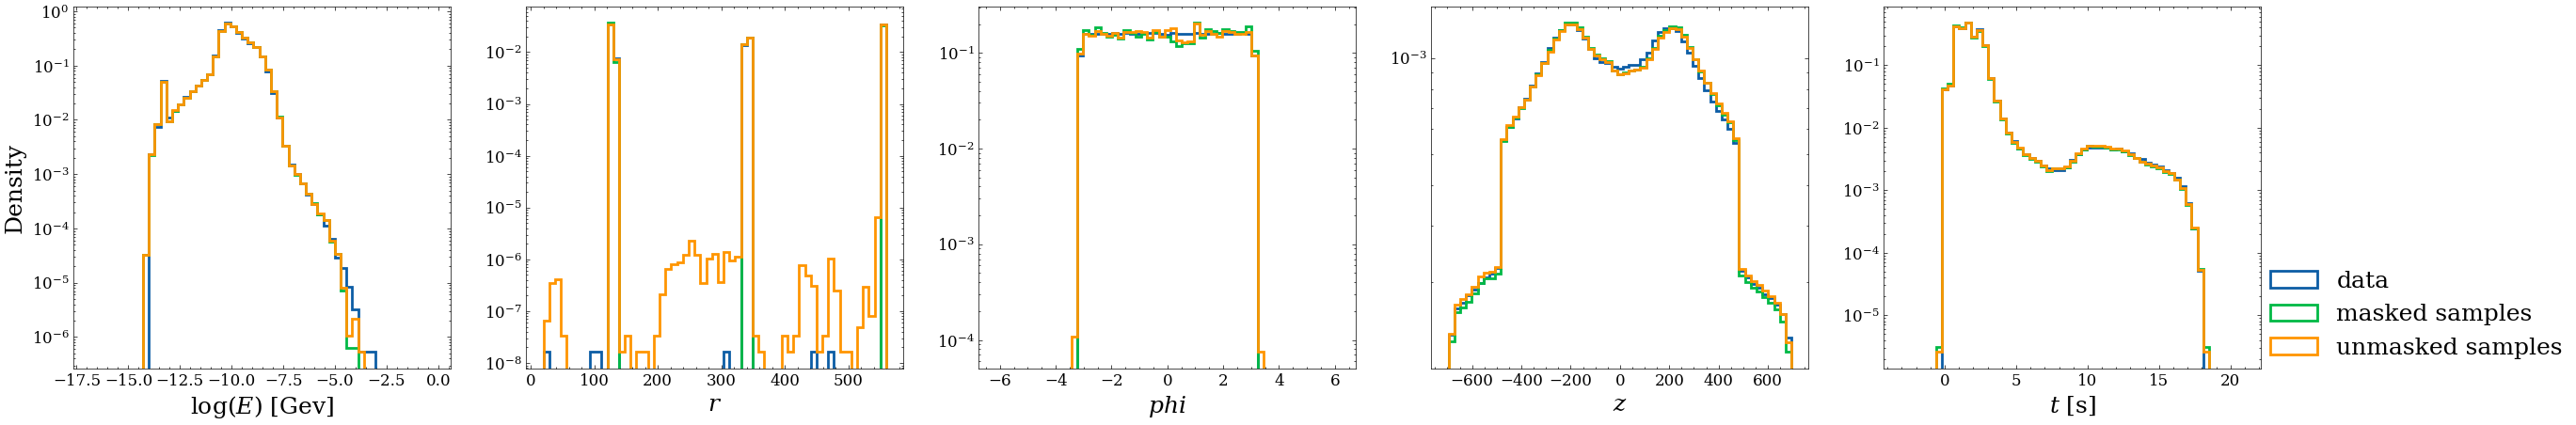

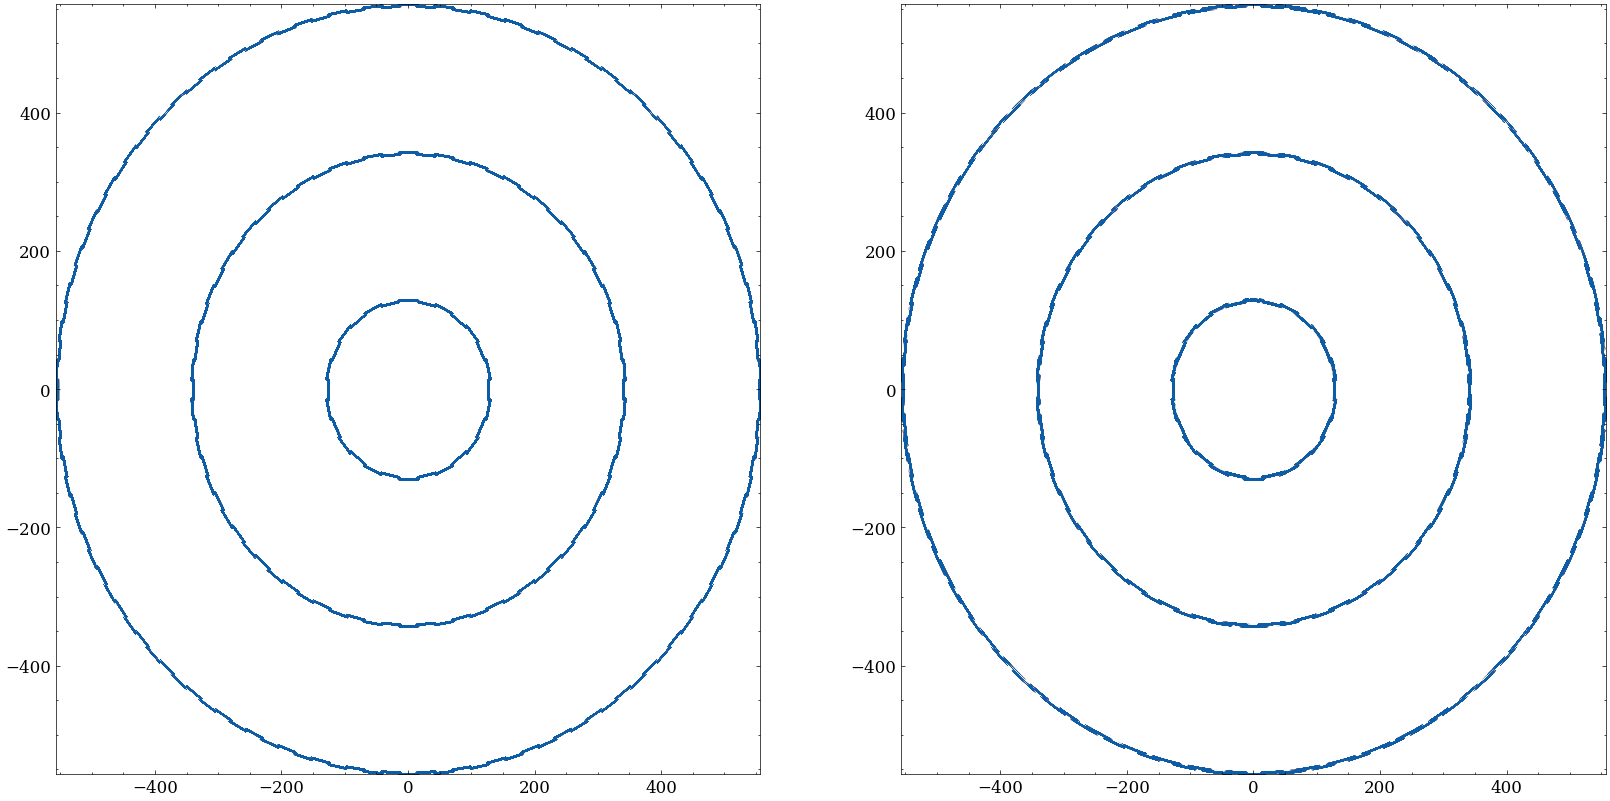

InnerTrackerEndcapCollection
74.86284088525834% of samples pass


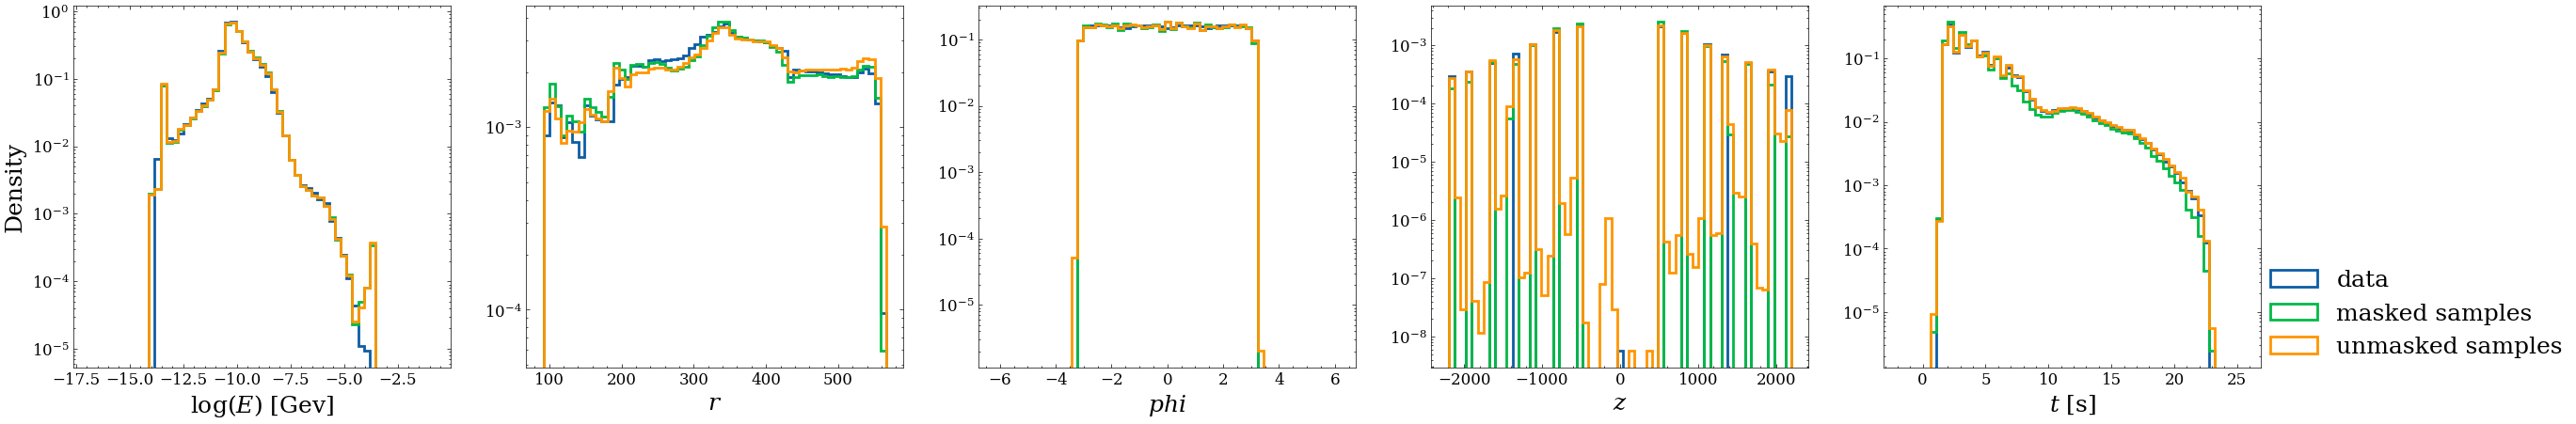

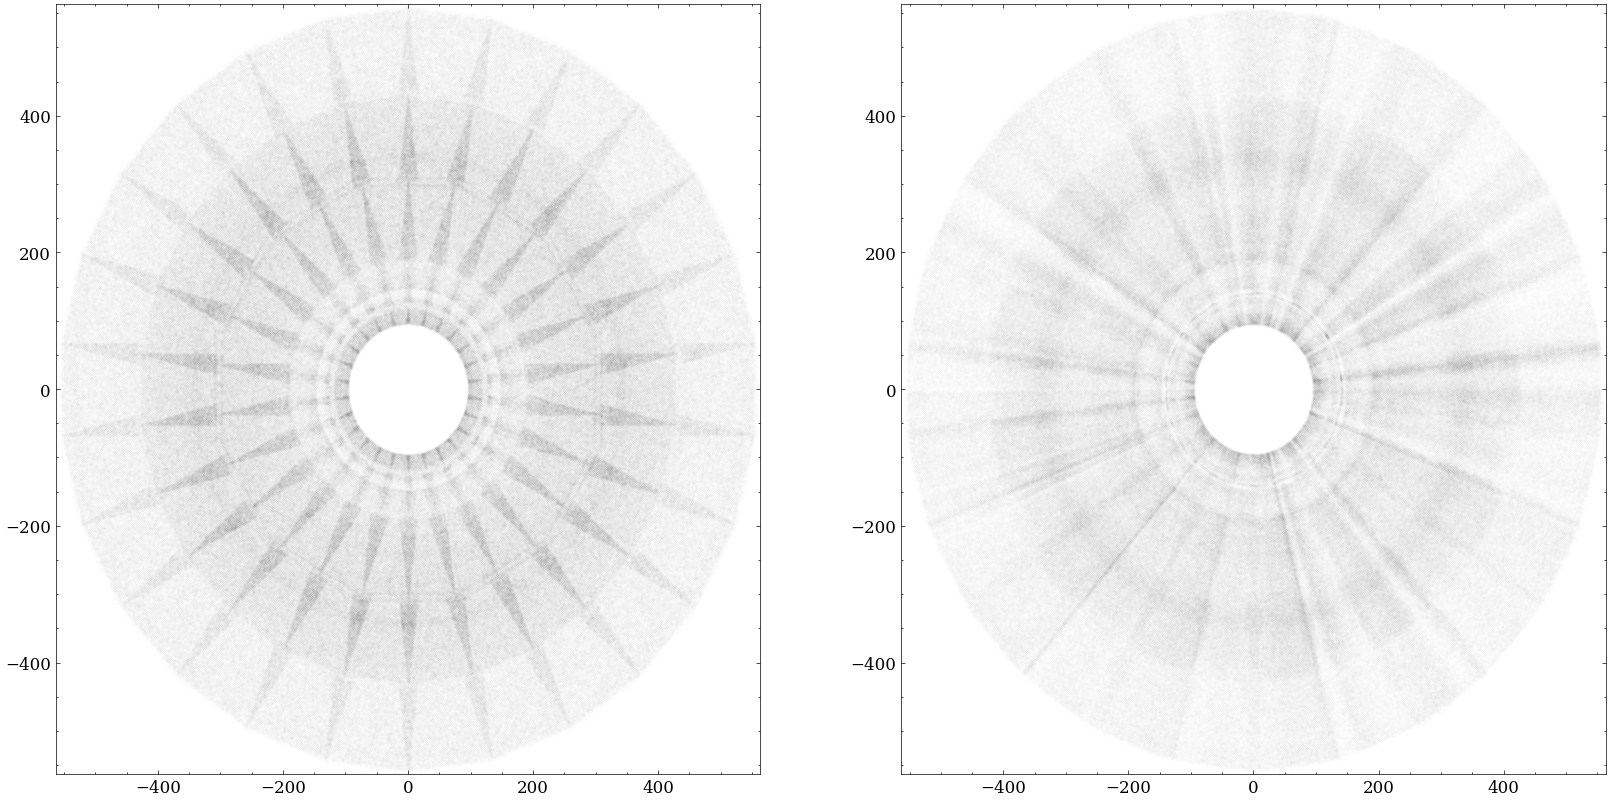

OuterTrackerBarrelCollection
89.23085082872929% of samples pass


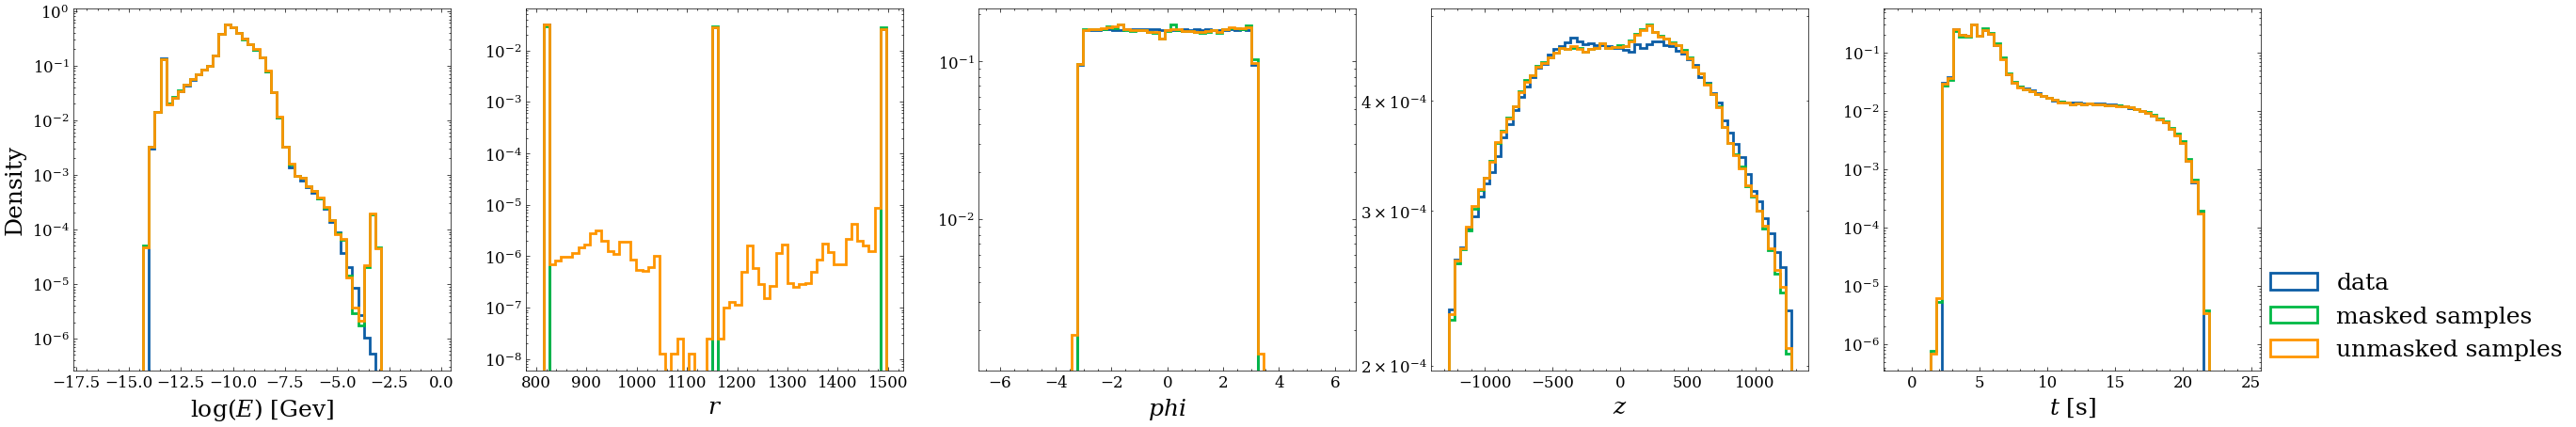

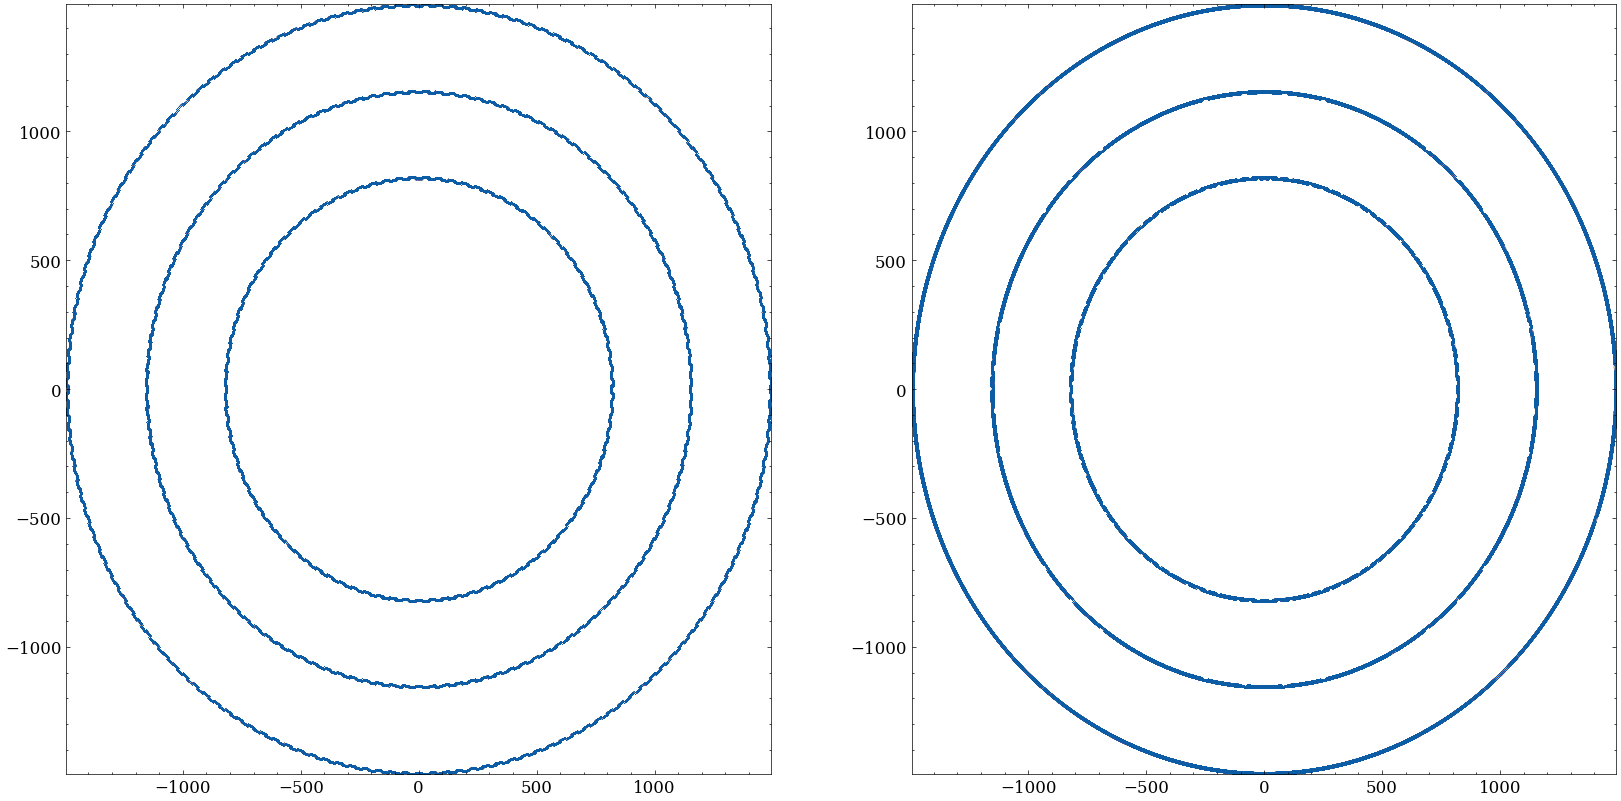

OuterTrackerEndcapCollection
89.74915290224979% of samples pass


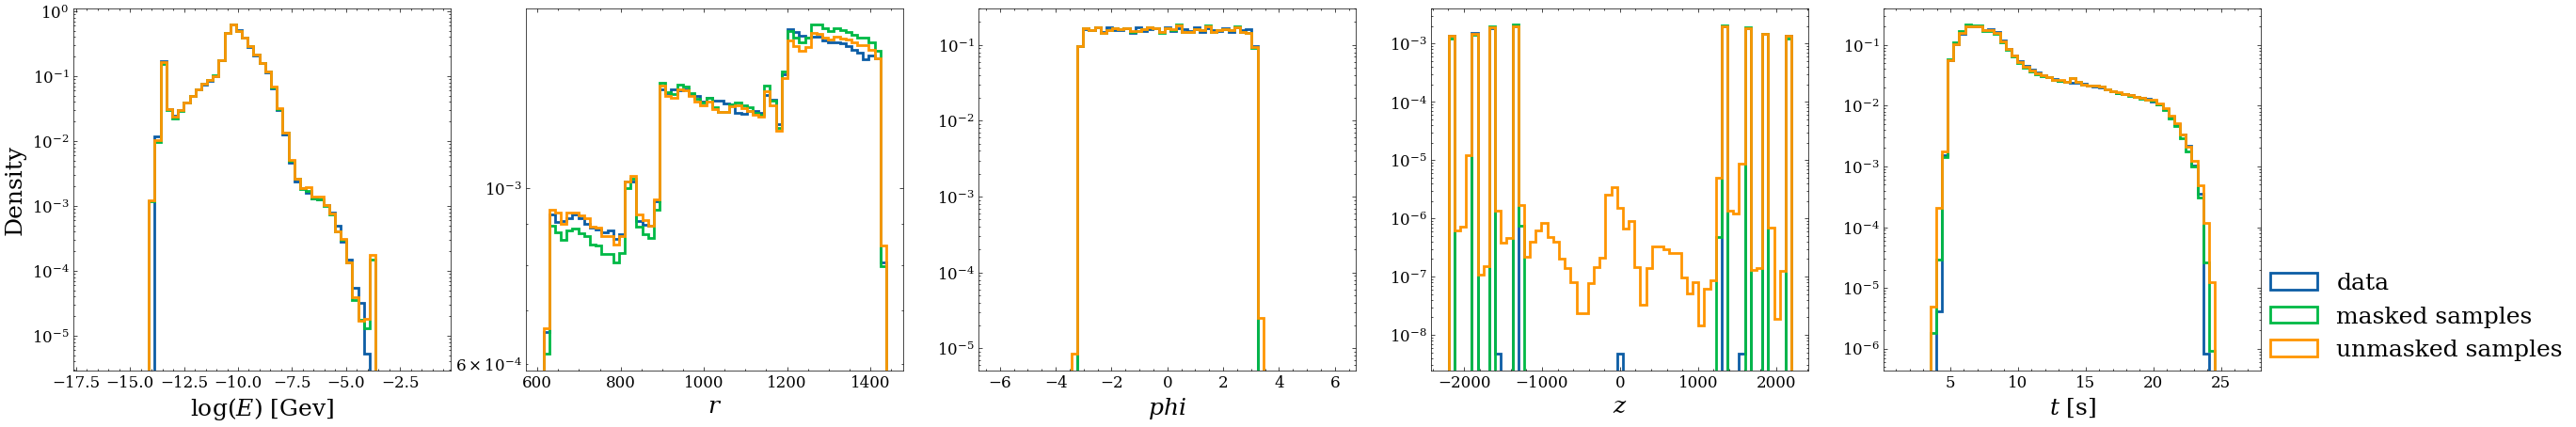

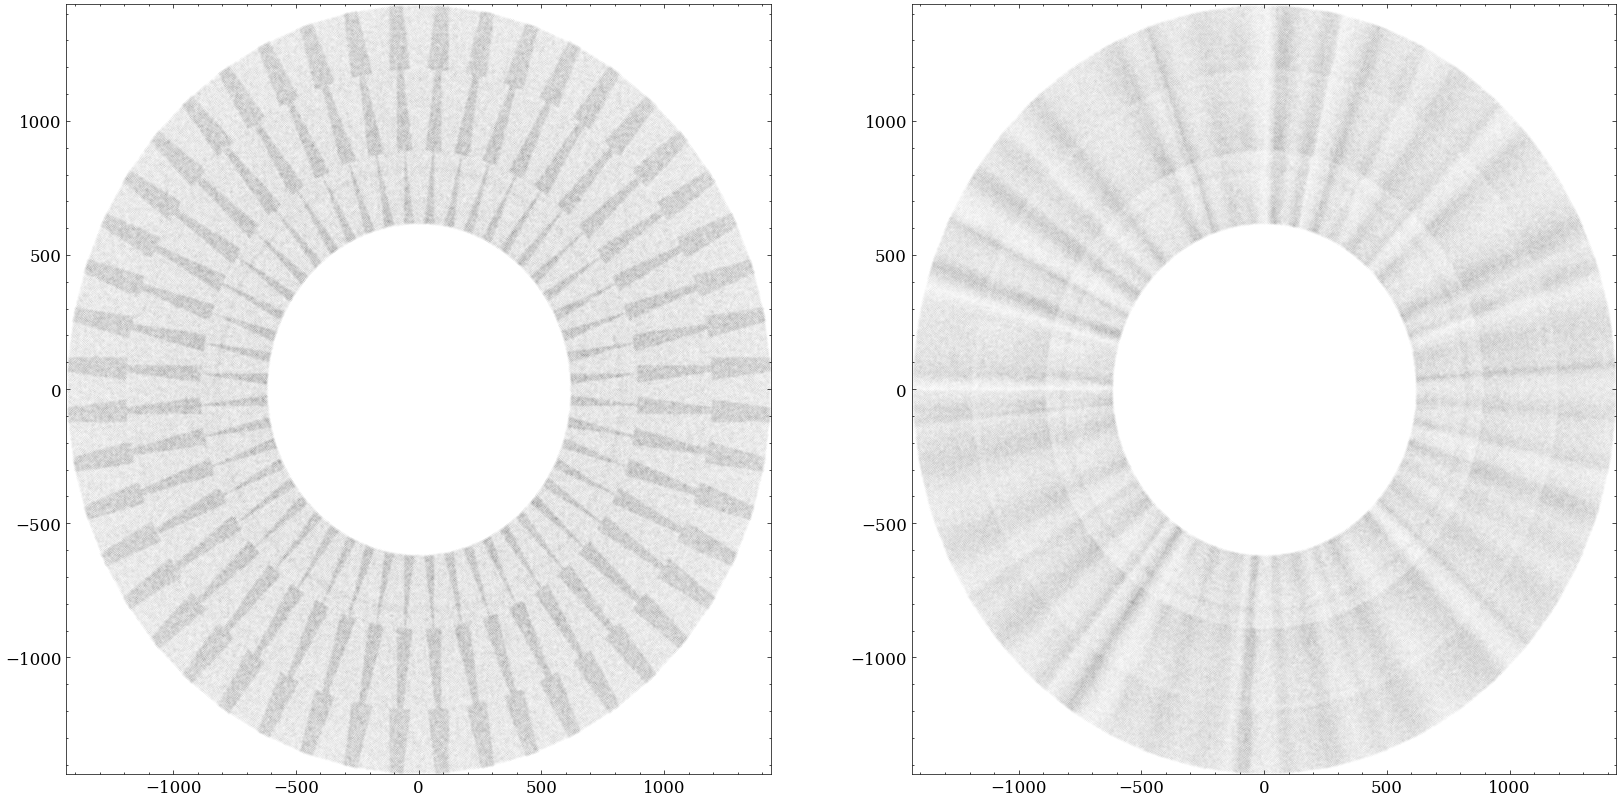

VertexBarrelCollection
65.41845376188037% of samples pass


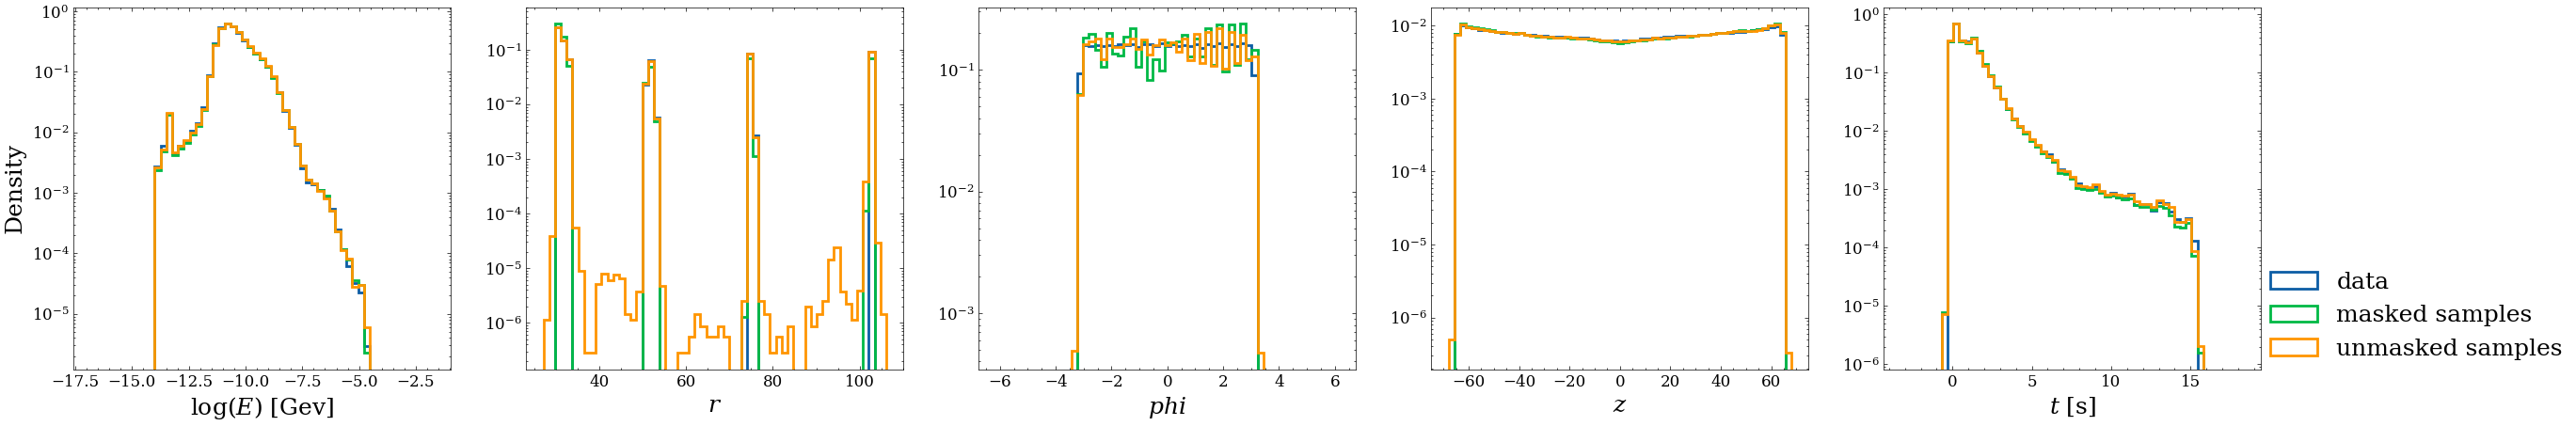

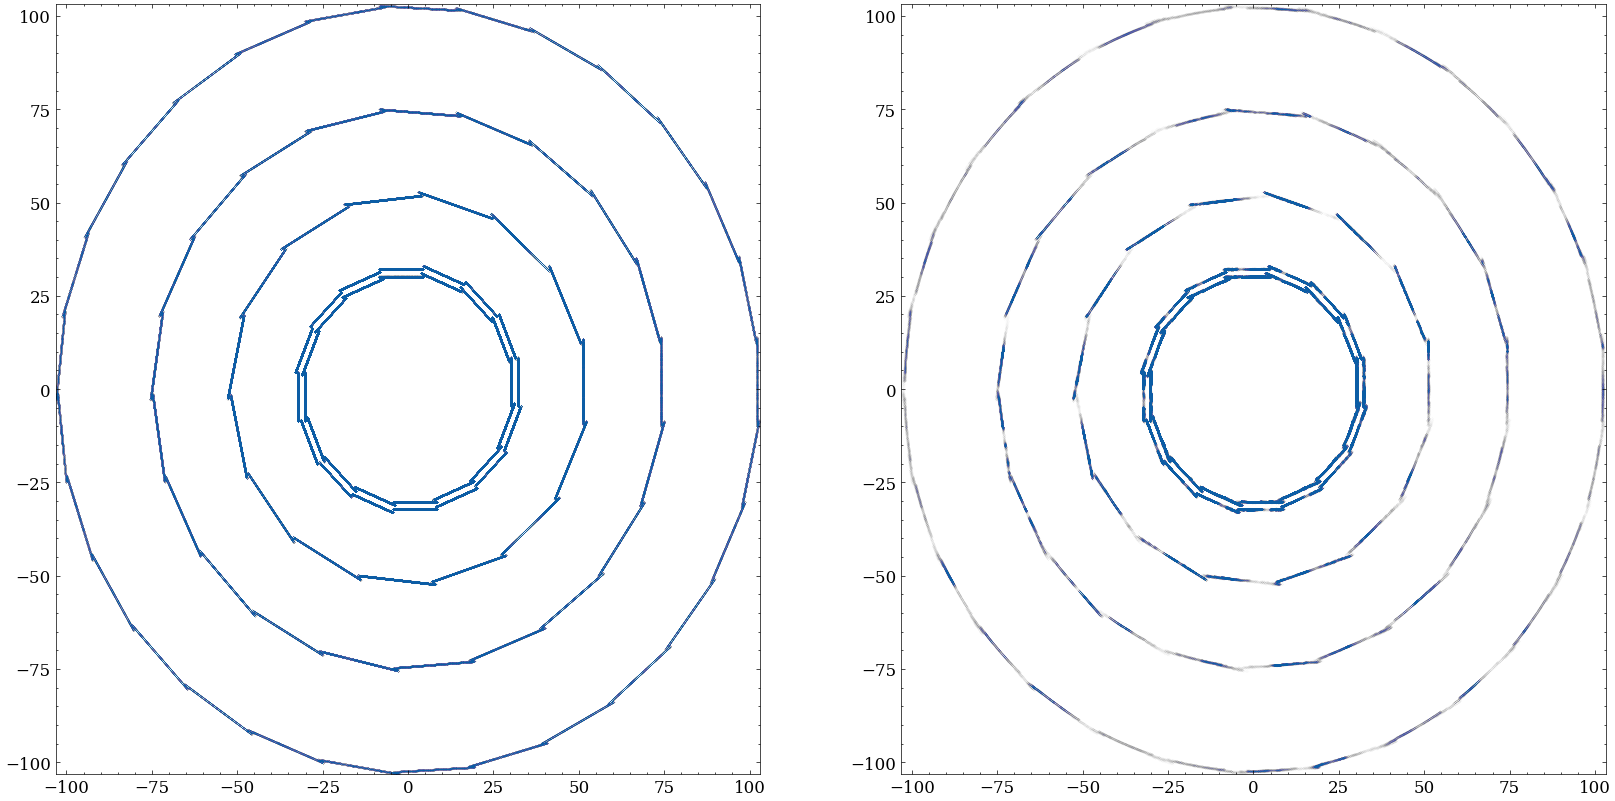

VertexEndcapCollection
91.20330496392377% of samples pass


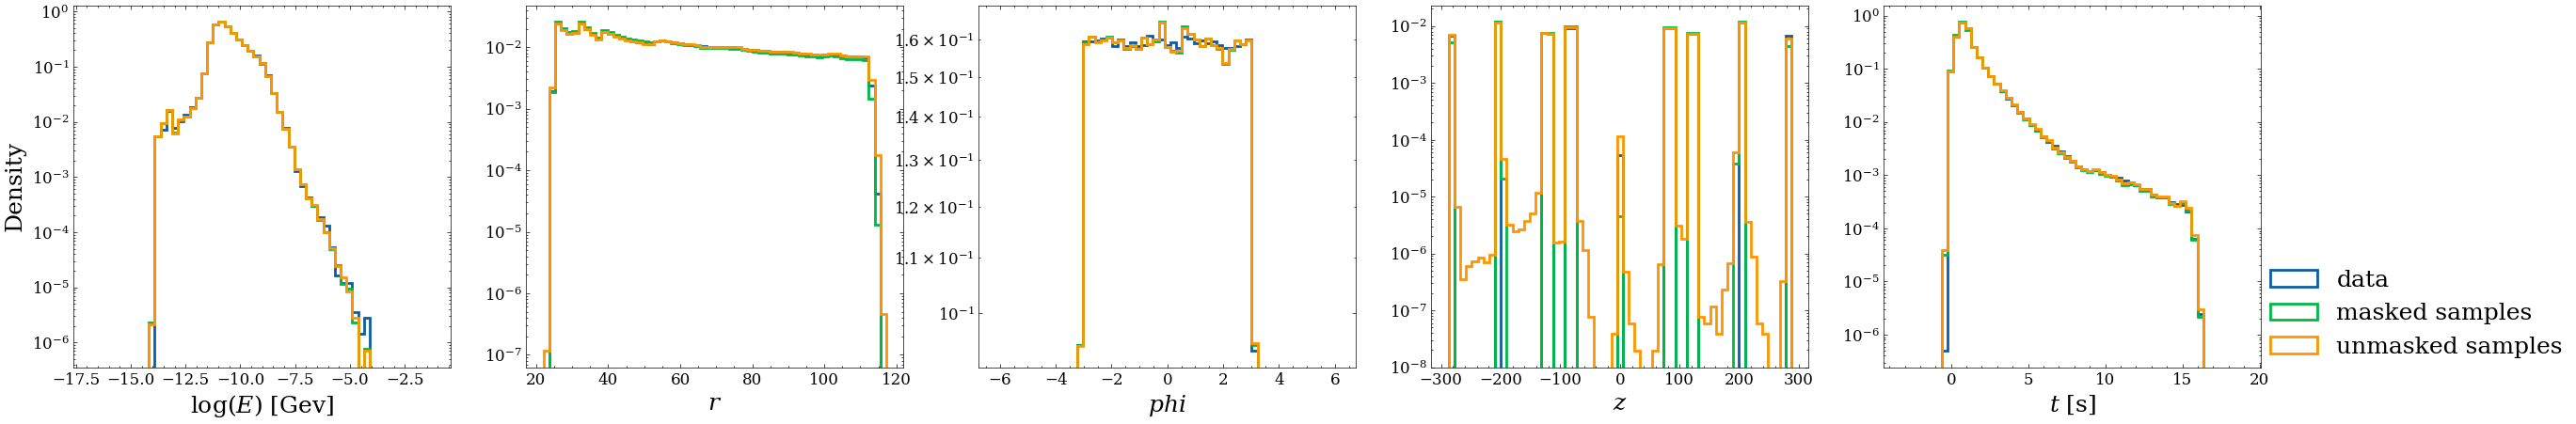

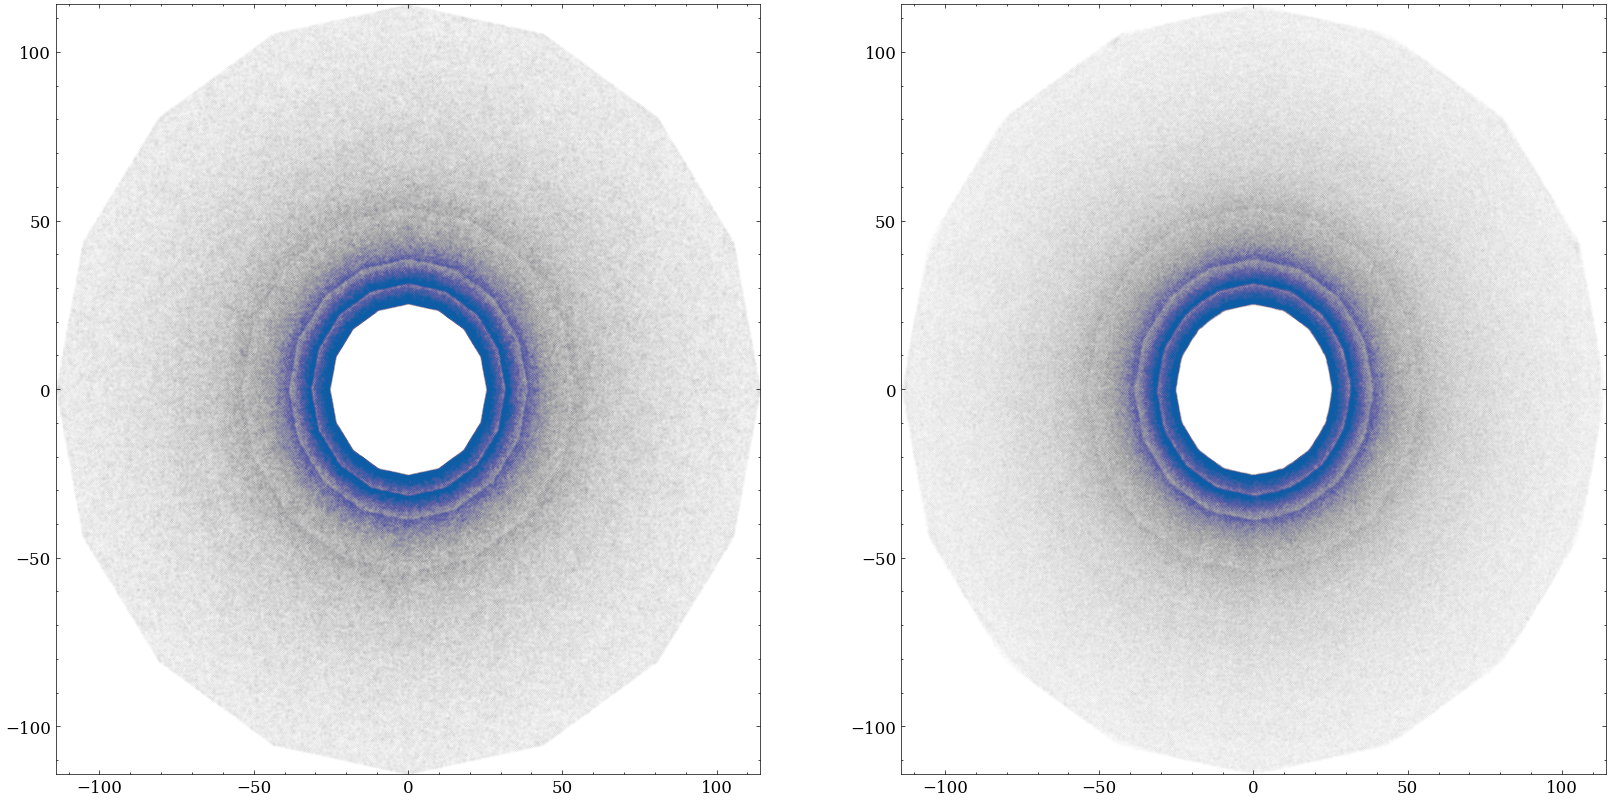

In [9]:

for col_name in collections:

    print(col_name)
    mask = apply_material_map(all_samples_dir, material_map, col_name)

    print(f"{100*sum(mask)/len(mask)}% of samples pass")
    plot_hists_1d({
        "data":all_data_dir[col_name], 
         "masked samples": all_samples_dir[col_name][mask],
        "unmasked samples":  all_samples_dir[col_name]
    }, bins_dict[col_name], log_dims=log_vars, labels=feature_labels)
    plt.savefig(f"figures/{col_name}_1d.png")

    # plot x-y
    x_lim = np.max(all_data_dir[col_name][:,1])
    fig, ax = plt.subplots(1, 2, figsize = (20, 10))
    ax[0].scatter(all_data_dir[col_name][:,1]*np.cos(all_data_dir[col_name][:,2]), all_data_dir[col_name][:,1]*np.sin(all_data_dir[col_name][:,2]), s = 0.00001)
    ax[0].set_xlim(-x_lim, x_lim)
    ax[0].set_ylim(-x_lim, x_lim)
    
    ax[1].scatter(all_samples_dir[col_name][mask][:,1]*np.cos(all_samples_dir[col_name][mask][:,2]), all_samples_dir[col_name][mask][:,1]*np.sin(all_samples_dir[col_name][mask][:,2]), s = 0.00001)
    ax[1].set_xlim(-x_lim, x_lim)
    ax[1].set_ylim(-x_lim, x_lim)
    plt.show()

   


In [10]:
def compute_feature_bdt_scores(data, samples, device="cuda"):
    """
    Train a 1D BDT per feature to discriminate data vs samples.
    Returns dict: feature_index -> (auc_mean, auc_std)
    """
    results = {}

    for i in range(data.shape[1]):
        data_feat = data[:, i].reshape(-1, 1)
        samples_feat = samples[:, i].reshape(-1, 1)

        auc_mean, auc_std, *_ = discriminate_data_from_samples(
            data_feat,
            samples_feat,
            3,
            "configs/bdt.yml",
            model_type="bdt",
            plot_losses=False,
            device=device,
            val_size=0.25,
            plot_dir="."
        )

        results[i] = (auc_mean, auc_std)
        print(f"Feature {i} BDT AUC: {auc_mean:.4f} ± {auc_std:.4f}")

    return results

In [11]:
import torch



device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)

def run_eval_suite(data, samples_dict, R_values, bins, plot_suffix=""):

    print(f"Len data: {len(data)}")

    loc_scores_list = []
    R_values_dict_samples = {R:[] for R in R_values}
    R_values_dict_data = {R:0 for R in R_values}
    R_values_bins = {R:0 for R in R_values}
    wasserstein_results = {key:{} for key in samples_dict.keys()}

    for sample_key in samples_dict.keys():
        loc_samples = samples_dict[sample_key]
        print(f"Len samples {sample_key}: {len(loc_samples)}")

    
        #Wasserstein dist
        # wass_dists_samples = get_wasserstein_dist(data, loc_samples)
        # wass_dists_gaussians = get_wasserstein_dist(np.random.normal(size = data.shape), np.random.normal(size = loc_samples.shape))                                            
        # print()
        # for i, wass_dist in enumerate(wass_dists_samples):
        #     wasserstein_results[sample_key][i] = wass_dist, wass_dists_gaussians[i]
        #     print("Feature {i} Wasserstein distance: {wass_dist} (for gaussian: {wass_dist_gauss})".format(i=i, wass_dist=wass_dist, wass_dist_gauss=wass_dists_gaussians[i]))
        # print()


        # Per-feature BDT evaluation
        print("\nPer-feature BDT performance:")
        bdt_feature_results = compute_feature_bdt_scores(data, loc_samples, device=device)

        wasserstein_results[sample_key] = bdt_feature_results
        print()
        # BDT
        auc_mean, auc_std, best_epoch_list, max_epochs, bdt_list, samples_test, loc_scores = discriminate_data_from_samples(
                                                data,
                                                loc_samples,
                                                3,
                                                "configs/bdt.yml",
                                                model_type="bdt",
                                                plot_losses=False,
                                                device="cuda",
                                                val_size = 0.25, 
                                                plot_dir="."
                                            )
    
        print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
        loc_scores_list.append(loc_scores)

        X_plot = {"samples":  samples_test}
        percentiles = [90, 95, 99, 99.9]
        for p in percentiles:
            X_plot[f"samples, top {p}%"] =  samples_test[loc_scores >= np.percentile(loc_scores, p)]
    
        plot_hists_1d({"data":data, **X_plot}, bins, log_dims=log_vars, labels=feature_labels)


        # Clustering
        for R in R_values:
            neighbor_counts_data = get_delta_R_neighbors_kdtree(data, R, FEATURES)
            neighbor_counts_flow = get_delta_R_neighbors_kdtree(loc_samples, R, FEATURES)
        
            max_val = np.max(neighbor_counts_data)
        
            bin_spacing = int(max_val/NUM_BINS)

            R_values_dict_data[R] = neighbor_counts_data
            R_values_dict_samples[R].append(neighbor_counts_flow)
            R_values_bins[R] = max_val, bin_spacing
           
            
    
    
        
    plt.figure()
    for i, sample_key in enumerate(samples_dict.keys()):
              
        plt.hist(loc_scores_list[i], bins = np.linspace(0, 1, 100), histtype = "step", density = True, label = sample_key)
    plt.yscale("log")
    plt.legend()
    plt.xlabel("scores")
    plt.ylabel("Density")
    plt.show()

    for R in R_values:
        plt.figure()
        
        for i, sample_key in enumerate(samples_dict.keys()):
            
            plt.hist(R_values_dict_samples[R][i], bins=np.arange(0, R_values_bins[R][0], R_values_bins[R][1]), histtype = "step", label = sample_key)
        plt.hist(R_values_dict_data[R], bins=np.arange(0, R_values_bins[R][0], R_values_bins[R][1]), histtype = "step", label = "data")
        plt.legend()
        plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")
        plt.ylabel("Count")
        plt.savefig(f"figures/deltaR{R}{plot_suffix}.png")
        plt.show()

    return wasserstein_results
        
        
        
        



Using device: cuda


<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\D'
<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2029209/1343289567.py:52: SyntaxWarning: invalid escape sequence '\p'
  print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
/tmp/ipykernel_2029209/1343289567.py:98: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")


Analyzing InnerTrackerBarrelCollection...
Len data: 150000
Len samples unmasked: 150000

Per-feature BDT performance:
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 0 BDT AUC: 0.5079 ± 0.0003
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 1 BDT AUC: 0.5807 ± 0.0001
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 2 BDT AUC: 0.5517 ± 0.0005
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 3 BDT AUC: 0.5067 ± 0.0002
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 4 BDT AUC: 0.5036 ± 0.0006

(150000, 5) (150000, 5)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
auc 0.6291203589925926 \pm 0.00370468836311961. best epoch [873, 510, 630] of 1000.

Len samples masked: 150000

Per-feature BDT performance:
(150000, 1) (150000, 1)
On BDT run 1 of 3.

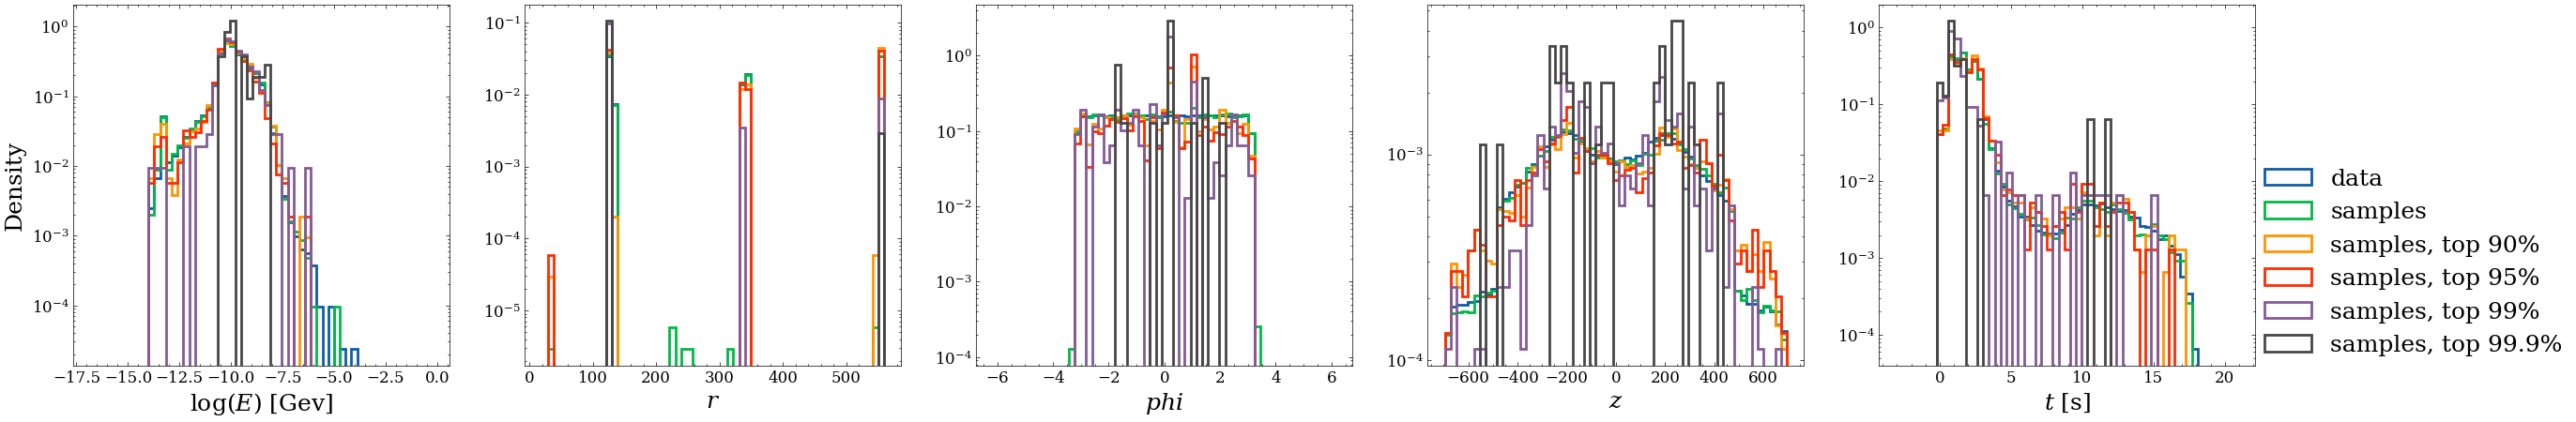

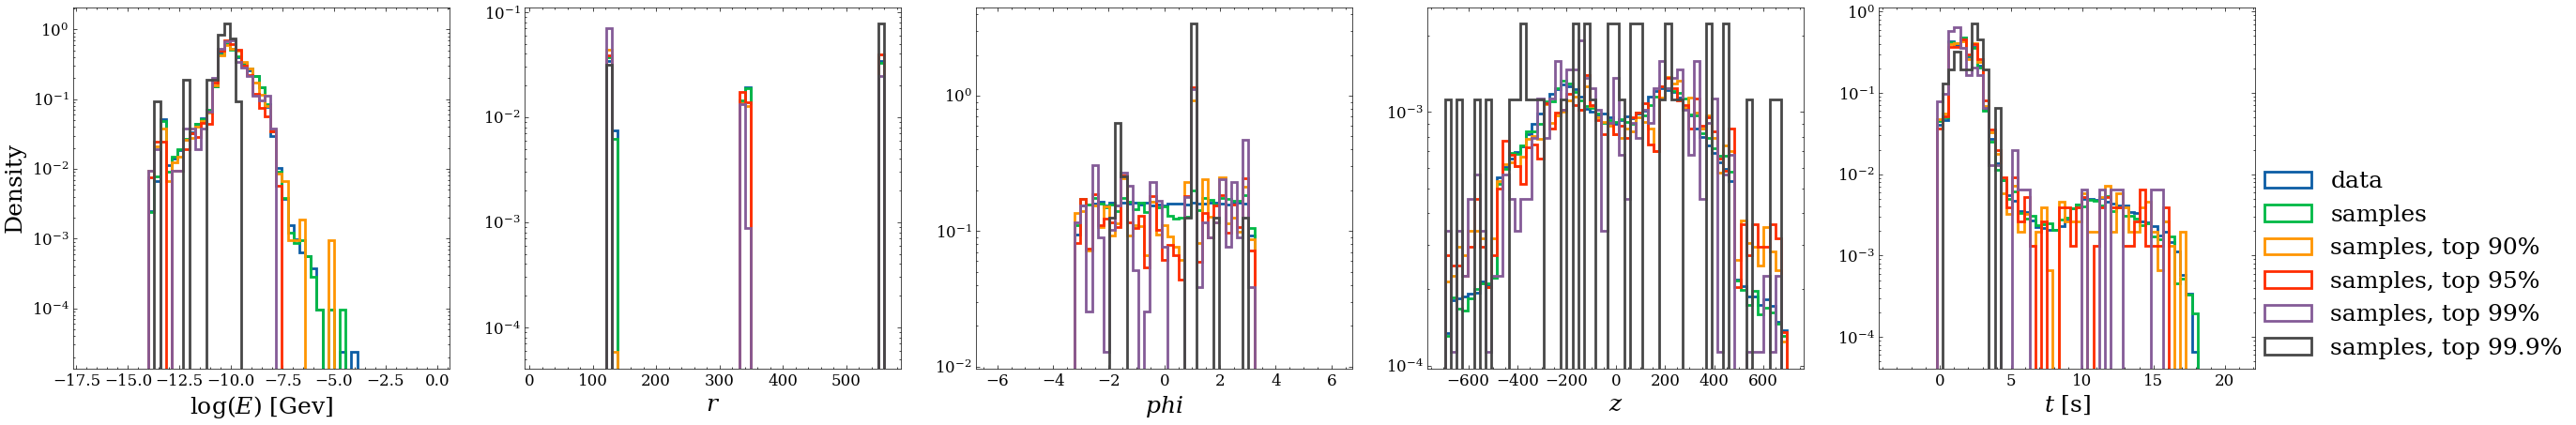

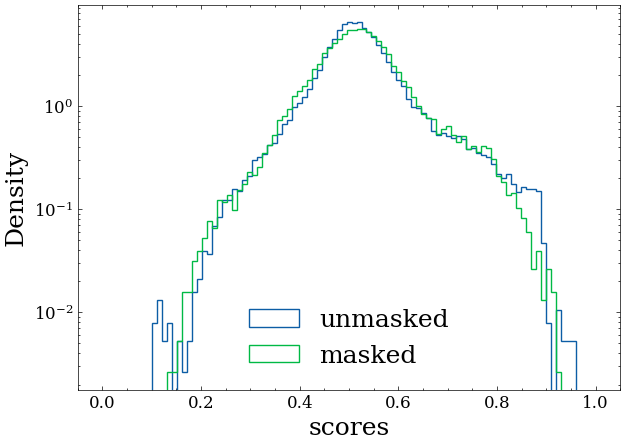

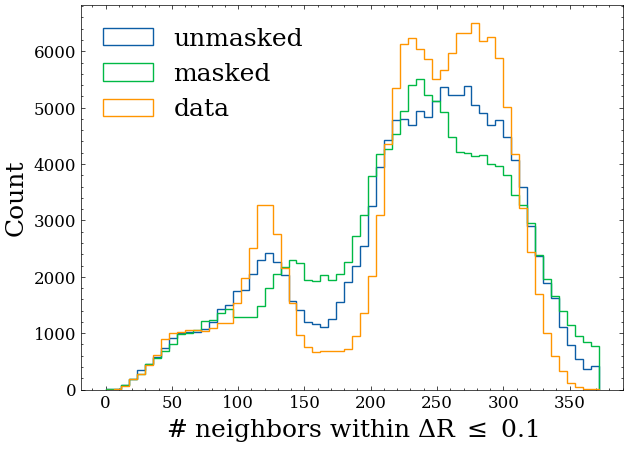

Analyzing InnerTrackerEndcapCollection...
Len data: 150000
Len samples unmasked: 150000

Per-feature BDT performance:
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 0 BDT AUC: 0.5163 ± 0.0001
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 1 BDT AUC: 0.5328 ± 0.0002
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 2 BDT AUC: 0.5545 ± 0.0002
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 3 BDT AUC: 0.9384 ± 0.0000
(150000, 1) (150000, 1)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
Feature 4 BDT AUC: 0.5127 ± 0.0001

(150000, 5) (150000, 5)
On BDT run 1 of 3...
On BDT run 2 of 3...
On BDT run 3 of 3...
auc 0.9497427326814815 \pm 5.914100345769428e-05. best epoch [999, 999, 999] of 1000.

Len samples masked: 150000

Per-feature BDT performance:
(150000, 1) (150000, 1)
On BDT run 1 of 

In [ ]:
all_w = {}

for col_name in collections:

    print(f"Analyzing {col_name}...")

    N = 150_000
    
    indices_1 = np.random.choice(all_data_dir[col_name].shape[0], size=N, replace=False)
    indices_2 = np.random.choice(all_samples_dir[col_name].shape[0], size=N, replace=False)
    mask = apply_material_map(all_samples_dir, material_map, col_name)

    indices_3 = np.random.choice(all_samples_dir[col_name][mask].shape[0], size=N, replace=False)

    all_w[col_name] = run_eval_suite(all_data_dir[col_name][indices_1], {"unmasked":all_samples_dir[col_name][indices_2], "masked":all_samples_dir[col_name][mask][indices_3]}, [0.1], bins_dict[col_name],
                       
                      plot_suffix=f"_{col_name}")

    


In [ ]:


plt.figure()
for i, col_name in enumerate(all_w.keys()):
    for key in all_w[col_name].keys():
        x_vals = all_w[col_name][key].keys()
        
        res = [all_w[col_name][key][x][0] for x in x_vals]
        res_gauss = [all_w[col_name][key][x][1] for x in x_vals]
        if key == "masked":
            plt.scatter(x_vals, res, color = f"C{i}", label = f"{col_name}, masked", marker="o", s=20)
        elif key == "unmasked":
            plt.scatter(x_vals, res, color = f"C{i}", label = f"{col_name}, unmasked", marker="*", s=50)
        plt.plot(x_vals, res_gauss, color = f"k")
plt.legend(loc=(1,0))
plt.xticks([0, 1, 2, 3, 4])
plt.yscale("log")
plt.xlabel("feature")

plt.ylabel("wasserstein distance")
plt.show()

In [ ]:
bins = 300
for col_name in collections:

    print(col_name)

    plt.figure(figsize = (10, 10))

    plt.hist2d(all_data_dir[col_name][:,1]*np.cos(all_data_dir[col_name][:,2]), 
               all_data_dir[col_name][:,1]*np.sin(all_data_dir[col_name][:,2]), 
               bins=(bins,bins),
              norm="log",)
    plt.show()
   
